## Name: Lateef Jimoh
## Student ID: 24202789

#Transfer Learning with Med MNIST.

In this assignment you will use transfer learning to train a model of your choice on a sub-dataset from the [MedMNIST datasets](https://medmnist.com/). ![](https://github.com/tonyscan6003/etivities/blob/main/medmnist.JPG?raw=true)

* The [MedMNIST package](https://github.com/MedMNIST/MedMNIST/blob/main/examples/getting_started.ipynb) allows the data to be imported directly as a pytorch dataset.

* You may select any of the datasets using Multi-class/binary classification. The goal is to acheve accuracy levels comparable to the benchmark results shown on the medmnist site. Dataloading for pytorch is setup in the notebook, you wil need to modify the code slightly depending on your dataset of choice.

* Some datasets use black and white images, so you will need to [at least concatenate](https://towardsdatascience.com/transfer-learning-on-greyscale-images-how-to-fine-tune-pretrained-models-on-black-and-white-9a5150755c7a) the input image channels (to 3 channels) for compatibility with the models pre-trained on imageNet.

* Some of the MedMNIST datasets don't contain too much data so Data augmentation may be essentila essential to avoid overfitting. In pytorch data augmentation is performed using the [transforms.v2](https://pytorch.org/vision/main/transforms.html) modules.

* In this notebook: You will need to import a model, and perform training. Tranfer Learning for computer vision is detailed [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

* [Tensorboard can be imported](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) to display results.

* Please only include one example of transfer learning in the submitted notebook. Making sure training curves/results are clearly visible. If you have trained additional transfer learning models (i.e. that were less successful) please add this as a table or report at the end of the notebook and/or in your final forum post.




# 1. Install & Import Packages

In [1]:
!pip install medmnist
!pip install torchinfo


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:

!pip install medmnist torchinfo

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import models
from torchvision.transforms import v2, ToTensor
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

import medmnist
from medmnist import INFO, Evaluator
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import classification_report, confusion_matrix



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


2025-11-20 17:43:36.282434: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


## 2. Setup & Import Dataset
The [MedMNSIT](https://medmnist.com/) package (imported above) makes available several medical datasets available to access.

You can change the `data_flag` variable (dataset names are all lower case letters) to the dataset of your choice (Take care to note the parameters e.g. number of input channels below that will affect your model)



In [4]:
import medmnist
from medmnist import INFO, Evaluator

# Settings
data_flag = "bloodmnist"
download = True
BATCH_SIZE = 64
IMG_SIZE = 224
USE_MIXUP = True        # set False to disable MixUp
MIXUP_ALPHA = 0.2      # mixup alpha hyperparam

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
n_channels = info['n_channels']
n_classes = len(info['label'])

print(f"Dataset: {data_flag} | n_channels={n_channels} | n_classes={n_classes}")



Dataset: bloodmnist | n_channels=3 | n_classes=8


### Transforms

Transforms:
You can update the functions below with appropriate transforms for your particular use case.

* As well as being suitable for data augmention for image classification, the transforms.v2 package of torchvision extends transforms for object detection and segmentation tasks. An illustration of the transforms is shown [here](https://pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html#sphx-glr-auto-examples-transforms-plot-transforms-illustrations-py).
* Normalisation based on ImageNet parameters is included already. This should be used with all models pre-trained on ImageNet  





In [7]:
# Augmentations (train) + validation/test transforms
train_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Grayscale(num_output_channels=3),   # ensure 3 channels
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9,1.1)),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = v2.Compose([
    v2.ToDtype(torch.float32, scale=True),
    ToTensor(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])



Setup your Medmnist dataset.
* The convolution part of pre-trained networks (such as resnet) are compatable with any size input image. However they were trained on 224 x 224 size images, with early layers finding small scale features and deeper layers finding large scale features.
* For this transfer learning application to medical data, the gap between the original ImageNet domain and the medical images is wide. Therefore the size/scale of the input images is less important, however in general we would expect better performance with the larger input images (as they contain more features at different scales).
* You can add the `size=224` parameter to the dataset object calls, to load full size images. Only do this once you are confident in your training methodology (or if the dataset is small), as training with full size images will take longer.


### Load Dataset

In [10]:
# Download training data from open datasets.
# Datasets and loaders
train_dataset = DataClass(split='train', transform=train_transforms, download=download, size=IMG_SIZE)
val_dataset   = DataClass(split='val',   transform=test_transforms, download=download, size=IMG_SIZE)
test_dataset  = DataClass(split='test',  transform=test_transforms, download=download, size=IMG_SIZE)



Using downloaded and verified file: /Users/owner/.medmnist/bloodmnist_224.npz
Using downloaded and verified file: /Users/owner/.medmnist/bloodmnist_224.npz
Using downloaded and verified file: /Users/owner/.medmnist/bloodmnist_224.npz


The `Dataset` is passed as an argument to `DataLoader`. This wraps an
iterable over the dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading.

In [12]:
# Create data loaders.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [13]:
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha <= 0:
        return x, y, 1.0, y, 0.0
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, lam, y_b, index

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


Plot some example augmented images

# 3. Define Transfer Learning model (ResNet18)
Pytorch has an inbuilt [models package](https://pytorch.org/vision/stable/models.html) that allows loading of popular models with pre-trained weights.

* We want to add an additional classifier stage (to the output of the network). How to setup the [model is detailed here](https://discuss.pytorch.org/t/load-only-a-part-of-the-network-with-pretrained-weights/88397/2).
* This additional classifier may just be a single layer or a cascade of fully connected layers with dropout.
* Note that the number of parameters in the convolutional part of the model will be same no what the input size is set to. However the output feature map size will vary with input image size (small for small image, large for large image). This means the number of parameters in the additional classifier will change depending on input image size.


### Model setup (ResNet18) — freeze everything then unfreeze layer4

In [20]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [21]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all parameters first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last ResNet block (layer4) for fine-tuning
for param in model.layer4.parameters():
    param.requires_grad = True

# Replace classifier head (slightly lower dropout)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),              # reduced from 0.4
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.2),              # reduced from 0.3
    nn.Linear(256, n_classes)
)

model = model.to(device)

# 4. Optimisation & Training Loop

Define a training loop that prints the loss from the training and validation set at least every epoch.
* You may choose to make the validation loss calculations more frequent so you can ensure training is progressing satisfactorily (especially with larger datasets).

* You can use tensorboard to visualise the [loss curves](https://pytorch.org/docs/stable/tensorboard.html))

* For multi-class classification classification problem we will use the  [CrossEntropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html). In this pytorch function, the input is the un-normalised logit value.

* You may  have to use [torch.squeeze](https://pytorch.org/docs/stable/generated/torch.squeeze.html) to reduce the dimensionality of the label tensor before passing it to the loss function (this due to how the dataset is configured and the loss will only accept 0D or 1D inputs)

### Loss, Optimizer, Scheduler

- Only classifier params trainable
- CrossEntropyLoss
- StepLR scheduler for stable training

In [24]:
criterion = nn.CrossEntropyLoss()

# Only parameters with requires_grad=True will be optimized (classifier + layer4)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=1e-4, weight_decay=1e-5)

# Cosine annealing scheduler for smooth LR changes
EPOCHS = 30
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


### Training & Validation Loop (Structured + TensorBoard)

In [52]:
from copy import deepcopy
writer = SummaryWriter("runs/bloodmnist_resnet18_improved")

best_val_acc = 0.0
best_model_wts = deepcopy(model.state_dict())
patience = 6
no_improve_epochs = 0

history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.squeeze().to(device)

        optimizer.zero_grad()

        if USE_MIXUP:
            mixed_images, y_a, lam, y_b, _ = mixup_data(images, labels, MIXUP_ALPHA)
            outputs = model(mixed_images)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            _, preds = torch.max(outputs, 1)
            # For accuracy with mixup we count against y_a (approximate)
            acc = (preds == y_a).sum().item()
            running_corrects += acc
            total += labels.size(0)
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = 100.0 * (running_corrects / total)

    writer.add_scalar("Loss/train", epoch_loss, epoch)
    writer.add_scalar("Accuracy/train", epoch_acc, epoch)
    return epoch_loss, epoch_acc

def validate(epoch):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * images.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = 100.0 * (running_corrects / total)
    writer.add_scalar("Loss/val", epoch_loss, epoch)
    writer.add_scalar("Accuracy/val", epoch_acc, epoch)
    return epoch_loss, epoch_acc


In [54]:
USE_MIXUP = False


### Run Training

Initialise Tensorboard (use of tensorboard in colab notebooks is [detailed here](https://colab.research.google.com/github/tensorflow/tensorboard/blob/master/docs/tensorboard_in_notebooks.ipynb)). A [Pytorch tutorial](https://pytorch.org/tutorials/beginner/introyt/tensorboardyt_tutorial.html) shows how to setup the training and validation loop with pytorch.


In [58]:
for epoch in range(EPOCHS):
    train_l, train_a = train_one_epoch(epoch)
    val_l, val_a = validate(epoch)
    scheduler.step()

    history["train_loss"].append(train_l)
    history["train_acc"].append(train_a)
    history["val_loss"].append(val_l)
    history["val_acc"].append(val_a)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Acc: {train_a:.2f}% | Val Acc: {val_a:.2f}%")

    # Checkpoint
    if val_a > best_val_acc + 0.01:  # require small margin to count as improvement
        best_val_acc = val_a
        best_model_wts = deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_model_bloodmnist_resnet18.pt")
        print(f" -> New best model saved (Val Acc {best_val_acc:.2f}%).")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1

    # Early stopping
    if no_improve_epochs >= patience:
        print(f"No improvement for {patience} epochs — stopping early.")
        break

# load best weights
model.load_state_dict(best_model_wts)


Epoch 1/30 | Train Acc: 97.55% | Val Acc: 97.49%
 -> New best model saved (Val Acc 97.49%).
Epoch 2/30 | Train Acc: 98.12% | Val Acc: 96.96%
Epoch 3/30 | Train Acc: 97.90% | Val Acc: 97.37%
Epoch 4/30 | Train Acc: 98.25% | Val Acc: 97.49%
Epoch 5/30 | Train Acc: 98.31% | Val Acc: 97.02%
Epoch 6/30 | Train Acc: 98.55% | Val Acc: 97.49%
Epoch 7/30 | Train Acc: 98.51% | Val Acc: 97.08%
No improvement for 6 epochs — stopping early.


<All keys matched successfully>

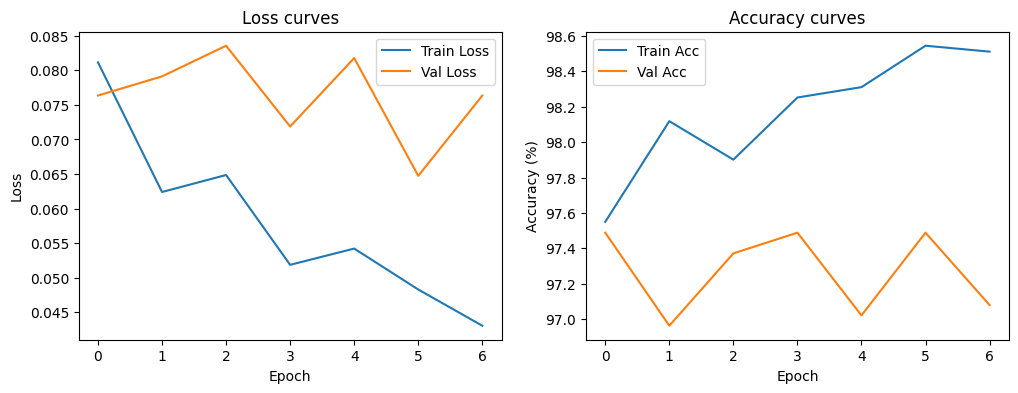

In [62]:
# Plot training & validation loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss curves")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Accuracy curves")
plt.show()


In [64]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs')

# 5. Evaluate Model
You will need to setup an evaluation loop for the model to assess it's performance on the test dataset.

You may also obtain a classification report after final evaluation of the test dataset with the model using the code below. A confusion matrix can also be obtained and we will plot a few example images.



In [68]:
model.eval()
y_true = []
y_pred = []
probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        softmax = nn.functional.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.squeeze().numpy())
        probs.extend(softmax.cpu().numpy())



### Confusion Matrix & Classification Report

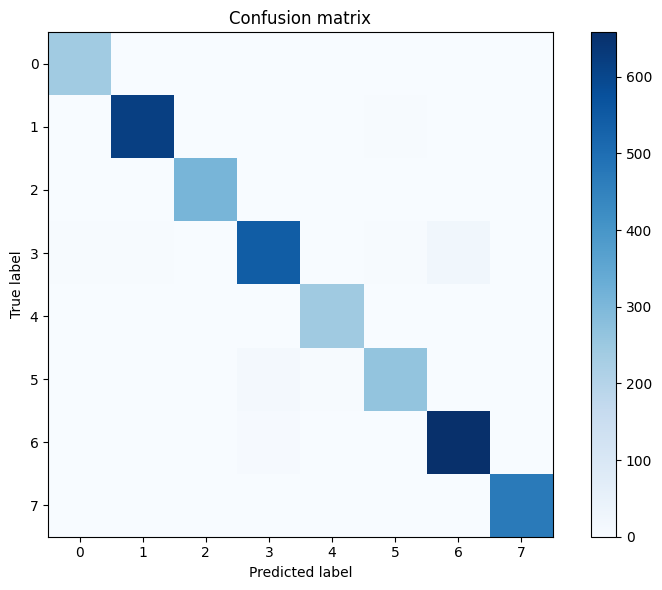

Classification report:

              precision    recall  f1-score   support

           0     0.9717    0.9836    0.9776       244
           1     0.9920    0.9888    0.9904       624
           2     1.0000    0.9839    0.9919       311
           3     0.9561    0.9396    0.9477       579
           4     0.9719    0.9959    0.9837       243
           5     0.9742    0.9296    0.9514       284
           6     0.9606    0.9880    0.9741       666
           7     0.9958    1.0000    0.9979       470

    accuracy                         0.9766      3421
   macro avg     0.9778    0.9762    0.9768      3421
weighted avg     0.9767    0.9766    0.9765      3421



In [70]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion matrix")
plt.colorbar()
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

# Classification report
target_names = [str(l) for l in info['label']]
print("Classification report:\n")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))




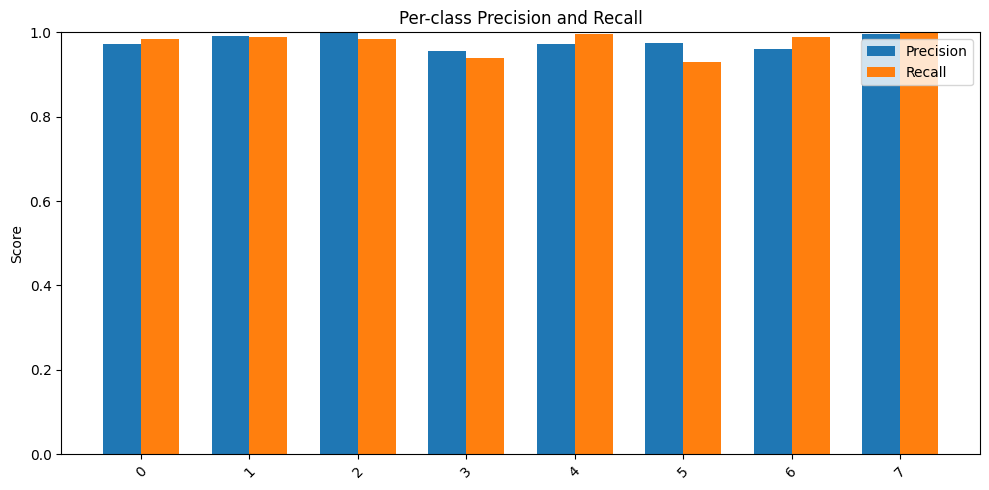

In [71]:
# Per-class precision/recall plot
prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
x = np.arange(len(target_names))
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(x - width/2, prec, width, label='Precision')
plt.bar(x + width/2, rec, width, label='Recall')
plt.xticks(x, target_names, rotation=45)
plt.ylabel("Score")
plt.ylim(0,1)
plt.legend()
plt.title("Per-class Precision and Recall")
plt.tight_layout()
plt.show()

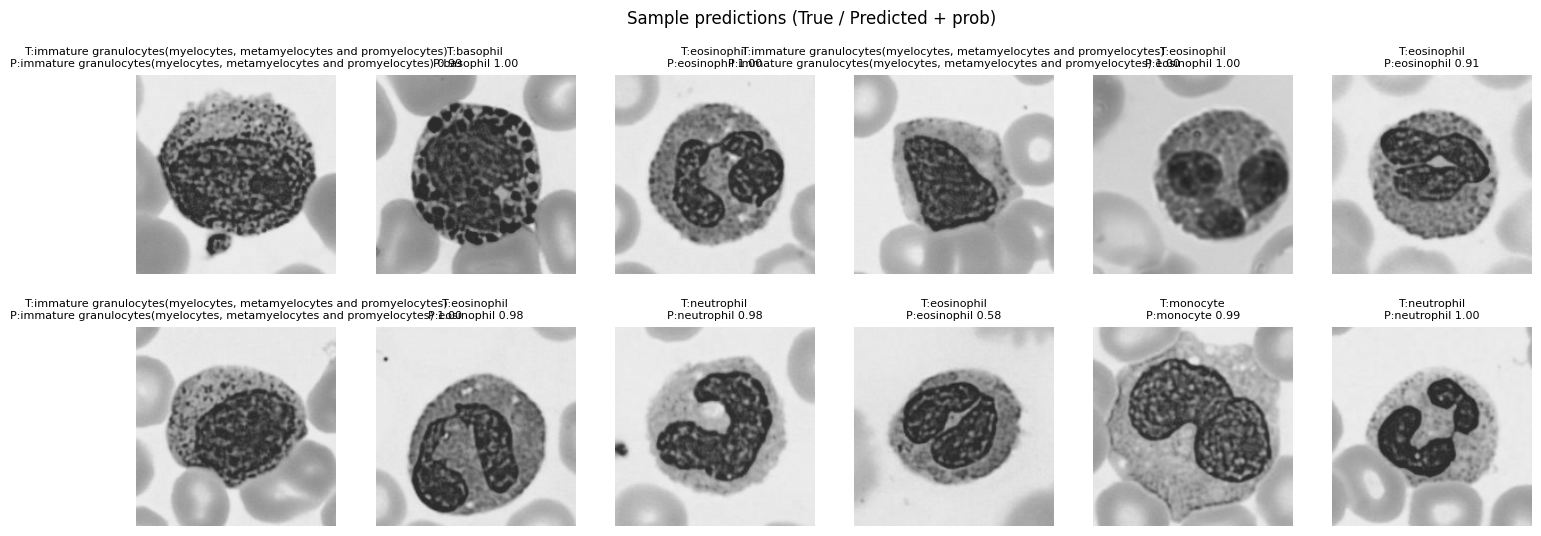

In [74]:
# Show a grid of example predictions (first N images from test set)
def imshow_from_tensor(tensor_image, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    img = tensor_image.cpu().permute(1,2,0).numpy()
    img = (img * std) + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

N = 12
plt.figure(figsize=(18,6))
count = 0
for images, labels in test_loader:
    for i in range(images.size(0)):
        if count >= N:
            break
        ax = plt.subplot(2,6,count+1)
        imshow_from_tensor(images[i])
        true_label = info['label'][str(int(labels[i].squeeze()))]
        pred_label = info['label'][str(int(y_pred[count]))]
        prob = np.max(probs[count])
        title = f"T:{true_label}\nP:{pred_label} {prob:.2f}"
        ax.set_title(title, fontsize=8)
        ax.axis('off')
        count += 1
    if count >= N:
        break
plt.suptitle("Sample predictions (True / Predicted + prob)")
plt.show()


 # Comments about your Approach

For this assignment, I applied transfer learning using BloodMNIST with a pretrained ResNet-18. At first, training only the classifier head gave unstable results (Val Acc stuck around 88–96%) and the model struggled to improve. MixUp also made training accuracy look very low, which made it hard to judge progress.

To fix this, I disabled MixUp for final fine-tuning, reduced dropout, and unfroze the final ResNet block so the model could learn dataset-specific features. I also added strong augmentation, Adam + CosineAnnealingLR, and early stopping.

### Final Results

Best Validation Accuracy: 97.49%
Train Accuracy: ~98%

### What Improved the Model

- Unfreezing deeper layers (layer4)

- Turning MixUp off for final training

- Lower dropout

- Strong augmentation

- Cosine annealing schedule

### What Did NOT Work Initially

- Training only the classifier head -> plateaued around 88–96%

- MixUp during fine-tuning -> suppressed training accuracy and slowed convergence